In [1]:
import pandas as pd
import numpy as np
import h5py
import os
import sys
from sklearn.model_selection import train_test_split
import torch
import psutil
import gc
import random
from datetime import datetime
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from util.datasets import *
from util.pos_embed import *

%load_ext autoreload
%autoreload 2

/opt/conda/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Dataset (prediction and ground truth)

In [2]:
data_path = "/niddk-data-central/mae_hr/rise_moca_4AP_20s_transition"

In [3]:
dataset_test = RISE(data_path=data_path, is_test=True, RISE_hz=30,  alt=True,
                     subject_level_analysis=True, use_transition_sub_label=True, cleanlab_filter=False)

1/2 split loading
1/2 split done
2/2 split loading
2/2 split done
Data loading all done: # X test samples = 3533434
After Exclusion: # X test samples = 3532068
unique y: [0 1 2 3 4 5 6]
y shape: torch.Size([3532068])


In [34]:
cleanlab_df_test = pd.read_csv(f"{data_path}/stat_feat_df/cleanlab_df_test.csv", index_col=0)
cleanlab_df_test

,is_label_issue,label_score,given_label,predicted_label,MoCA_pred,given_label_chr,MoCA_pred_chr,predicted_label_chr
0,False,0.407065,6,6,6,Transition-mixed,Transition-mixed,Transition-mixed
1,False,0.831456,0,0,0,Sedentary,Sedentary,Sedentary
2,False,0.855696,0,0,0,Sedentary,Sedentary,Sedentary
3,False,0.678562,0,0,0,Sedentary,Sedentary,Sedentary
4,False,0.387842,0,0,0,Sedentary,Sedentary,Sedentary
...,...,...,...,...,...,...,...,...
3532063,False,0.938820,4,4,4,Seated_Transport,Seated_Transport,Seated_Transport
3532064,False,0.941834,4,4,4,Seated_Transport,Seated_Transport,Seated_Transport
3532065,False,0.923064,4,4,4,Seated_Transport,Seated_Transport,Seated_Transport
3532066,False,0.933103,4,4,4,Seated_Transport,Seated_Transport,Seated_Transport


In [39]:
(torch.tensor(cleanlab_df_test['given_label']) == dataset_test.y).sum()

tensor(3532068)

# Regression dataset

## rows = intervals

In [51]:
# trt
trt_arms = pd.read_csv("/niddk-data-central/P2/CHAP2.0_support_files/P2_3arm_rand.csv")
trt_arms["study_id"] = trt_arms["study_id"].astype(int)

id_to_arm = dict(zip(trt_arms["study_id"], trt_arms["rand_assignment"]))
trt_test = torch.tensor([id_to_arm[int(sid.item())] for sid in dataset_test.id.flatten()])

mapping = torch.tensor([0, 1, 1, 0, 0, 1, 2], dtype=torch.long)
pred = cleanlab_df_test['MoCA_pred'].values
target = cleanlab_df_test['given_label'].values
categories_3_pred = mapping[pred]
categories_3 = mapping[target]



sub_analysis_test = pd.DataFrame({
    'cat7' : target,
    'cat7_pred': pred,
    'cat3_sam' : categories_3,
    'cat3_sam_pred': categories_3_pred,
    'treatment' : trt_test.squeeze().numpy(),
    'id': dataset_test.id.squeeze().numpy(),
    'visit': dataset_test.visit.squeeze().numpy(),
    'time': pd.to_datetime(dataset_test.time.squeeze().numpy(), unit='s'),
    'is_label_issue': cleanlab_df_test['is_label_issue'].values
})

# assign treatment
sub_analysis_test['test_group'] = 1

#sub_analysis_df = pd.concat([sub_analysis_test, sub_analysis_train]) # combine into one df
sub_analysis_df = sub_analysis_test

# separate out date and clock_time
sub_analysis_df['date'] = sub_analysis_df['time'].dt.date
sub_analysis_df['clock_time'] = sub_analysis_df['time'].dt.time


# add total time
total_time = (sub_analysis_df.groupby(['id', 'visit', 'date']).size().reset_index(name='n_intervals'))
sub_analysis_df = sub_analysis_df.merge(total_time, on=['id', 'visit', 'date'], how="left")
sub_analysis_df.drop('time', axis=1)

# add day
sub_analysis_df = sub_analysis_df.sort_values(['id', 'visit', 'date'])
sub_analysis_df['date'] = pd.to_datetime(sub_analysis_df['date'].values)
sub_analysis_df['day'] = (sub_analysis_df.groupby(['id', 'visit'])['date'].transform(lambda x: pd.factorize(x.dt.date)[0]))

# filter according to cleanlab
sub_analysis_df = sub_analysis_df[sub_analysis_df['is_label_issue'] == 0]

# save
sub_analysis_df = sub_analysis_df.drop('time', axis=1)
sub_analysis_df.to_csv(f"{data_path}/NEW_sub_analysis_df.csv", index=False)
sub_analysis_df = pd.read_csv(f"{data_path}/NEW_sub_analysis_df.csv")


In [52]:
sub_analysis_df

,cat7,cat7_pred,cat3_sam,cat3_sam_pred,treatment,id,visit,is_label_issue,test_group,date,clock_time,n_intervals,day
0,5,5,1,1,0,200267,0,False,1,2018-06-27,07:36:59,2799,0
1,5,5,1,1,0,200267,0,False,1,2018-06-27,07:37:19,2799,0
2,5,5,1,1,0,200267,0,False,1,2018-06-27,07:37:39,2799,0
3,1,1,1,1,0,200267,0,False,1,2018-06-27,07:37:59,2799,0
4,5,5,1,1,0,200267,0,False,1,2018-06-27,07:38:19,2799,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2875809,3,0,0,0,1,241254,1,False,1,2022-08-20,20:57:39,2160,4
2875810,3,0,0,0,1,241254,1,False,1,2022-08-20,20:58:19,2160,4
2875811,3,0,0,0,1,241254,1,False,1,2022-08-20,20:59:59,2160,4
2875812,3,0,0,0,1,241254,1,False,1,2022-08-20,21:00:59,2160,4


## rows = days


In [53]:
# make summarized df
ti_delta = 20


total_time = (sub_analysis_df.groupby(['id', 'visit', 'date', 'day', 'test_group']).size().reset_index(name='n_intervals'))
total_time['total_hr'] = total_time['n_intervals'] * ti_delta / 3600


cat3_sam_pred_summary = (sub_analysis_df.groupby(['id', 'visit', 'date', 'cat3_sam_pred', 'day', 'test_group']).size().reset_index(name='n_intervals'))
cat3_sam_pred_summary['time_hr'] = cat3_sam_pred_summary['n_intervals'] * ti_delta / 3600
cat3_sam_pred_pivot = cat3_sam_pred_summary.pivot_table(index=['id', 'visit', 'date', 'day'], columns='cat3_sam_pred', values='time_hr', fill_value=0).reset_index()
cat3_sam_pred_pivot = cat3_sam_pred_pivot.rename(columns={c: f"cat3_sam_pred_{c}" for c in cat3_sam_pred_pivot.columns if c not in ['id', 'visit', 'date', 'day']})


cat3_sam_summary = (sub_analysis_df.groupby(['id', 'visit', 'date', 'cat3_sam', 'day', 'test_group']).size().reset_index(name='n_intervals'))
cat3_sam_summary['time_hr'] = cat3_sam_summary['n_intervals'] * ti_delta / 3600
cat3_sam_pivot = cat3_sam_summary.pivot_table(index=['id', 'visit', 'date', 'day'], columns='cat3_sam', values='time_hr', fill_value=0).reset_index()
cat3_sam_pivot = cat3_sam_pivot.rename(columns={c: f"cat3_sam_{c}" for c in cat3_sam_pivot.columns if c not in ['id', 'visit', 'date', 'day']})

#merge data
summary_df = (total_time.merge(cat3_sam_pred_pivot, on=['id', 'visit', 'date', 'day'], how='left').merge(cat3_sam_pivot, on=['id', 'visit', 'date', 'day'], how='left'))
treatment_df = (sub_analysis_df.groupby(['id', 'visit'], as_index=False)['treatment'].first())
summary_df_fin = summary_df.merge(treatment_df, on=['id', 'visit'], how='left' )


cat3_sam_cols = [c for c in cat3_sam_pivot.columns if c not in ['id', 'visit', 'date', 'clock_time', 'time', 'day', 'test_group']]
cat3_sam_pred_cols = [c for c in cat3_sam_pred_pivot.columns if c not in ['id', 'visit', 'date', 'clock_time', 'time', 'day', 'test_group']]


for c in cat3_sam_cols + cat3_sam_pred_cols:
    summary_df_fin[f'{c}_prop'] = (summary_df_fin[c] / summary_df_fin['total_hr'])


cat3_sam_cols_prop = [f'{c}_prop' for c in cat3_sam_cols]
cat3_sam_pred_cols_prop = [f'{c}_prop' for c in cat3_sam_pred_cols]


summary_df_fin[['id', 'visit', 'date', 'total_hr', 'treatment', 'day', 'test_group'] + cat3_sam_cols + cat3_sam_pred_cols + cat3_sam_cols_prop + cat3_sam_pred_cols_prop]

,id,visit,date,total_hr,treatment,day,test_group,cat3_sam_0,cat3_sam_1,cat3_sam_2,cat3_sam_pred_0,cat3_sam_pred_1,cat3_sam_pred_2,cat3_sam_0_prop,cat3_sam_1_prop,cat3_sam_2_prop,cat3_sam_pred_0_prop,cat3_sam_pred_1_prop,cat3_sam_pred_2_prop
0,200267,0,2018-06-27,13.822222,0,0,1,9.766667,3.877778,0.177778,8.850000,4.833333,0.138889,0.706592,0.280547,0.012862,0.640273,0.349678,0.010048
1,200267,0,2018-06-28,10.822222,0,1,1,6.538889,4.116667,0.166667,6.961111,3.755556,0.105556,0.604209,0.380390,0.015400,0.643224,0.347023,0.009754
2,200267,0,2018-06-29,13.933333,0,2,1,8.883333,4.927778,0.122222,9.394444,4.461111,0.077778,0.637560,0.353668,0.008772,0.674242,0.320175,0.005582
3,200267,0,2018-06-30,7.783333,0,3,1,4.722222,2.972222,0.088889,4.755556,2.961111,0.066667,0.606709,0.381870,0.011420,0.610992,0.380443,0.008565
4,200267,0,2018-07-01,14.233333,0,4,1,10.311111,3.816667,0.105556,10.538889,3.616667,0.077778,0.724434,0.268150,0.007416,0.740437,0.254098,0.005464
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1320,241254,1,2022-08-16,10.716667,1,0,1,5.933333,4.755556,0.027778,6.077778,4.605556,0.033333,0.553655,0.443753,0.002592,0.567133,0.429756,0.003110
1321,241254,1,2022-08-17,7.616667,1,1,1,6.861111,0.722222,0.033333,6.777778,0.783333,0.055556,0.900802,0.094821,0.004376,0.889861,0.102845,0.007294
1322,241254,1,2022-08-18,5.288889,1,2,1,4.866667,0.383333,0.038889,4.844444,0.405556,0.038889,0.920168,0.072479,0.007353,0.915966,0.076681,0.007353
1323,241254,1,2022-08-19,12.677778,1,3,1,11.566667,1.016667,0.094444,11.661111,0.944444,0.072222,0.912358,0.080193,0.007450,0.919807,0.074496,0.005697


In [54]:
# sanity check
sanity_check = False
if sanity_check:

    
    sanity_check_df = summary_df_fin.copy()
    sanity_check_df['cat3_sum_hr'] = sanity_check_df[cat3_sam_cols].sum(axis=1)
    sanity_check_df['cat3_sum_pct'] = sanity_check_df[[f'{c}_prop' for c in cat3_sam_cols]].sum(axis=1)

    print(np.sum(np.where(sanity_check_df[['cat3_sum_pct']].values != 1)[1]))
    sanity_check_df['cat3_hr_diff'] = sanity_check_df['total_hr'] - sanity_check_df['cat3_sum_hr']

    # Display subjects where something seems off
    check_df = sanity_check_df.loc[
        (sanity_check_df['cat3_sum_pct'].round(2) != 1.00) |
        (sanity_check_df['cat3_hr_diff'].abs() > 1e-6),
        ['id', 'visit', 'total_hr', 'cat3_sum_hr', 'cat3_hr_diff', 'cat3_sum_pct']
    ]

    print(f"{len(check_df)} rows failed sanity check")


In [55]:
summary_df_fin.to_csv(f"{data_path}/NEW_sub_analysis_summary.csv", index=False)
summary_df_fin = pd.read_csv(f"{data_path}/NEW_sub_analysis_summary.csv")

In [56]:
summary_df_fin

,id,visit,date,day,test_group,n_intervals,total_hr,cat3_sam_pred_0,cat3_sam_pred_1,cat3_sam_pred_2,cat3_sam_0,cat3_sam_1,cat3_sam_2,treatment,cat3_sam_0_prop,cat3_sam_1_prop,cat3_sam_2_prop,cat3_sam_pred_0_prop,cat3_sam_pred_1_prop,cat3_sam_pred_2_prop
0,200267,0,2018-06-27,0,1,2488,13.822222,8.850000,4.833333,0.138889,9.766667,3.877778,0.177778,0,0.706592,0.280547,0.012862,0.640273,0.349678,0.010048
1,200267,0,2018-06-28,1,1,1948,10.822222,6.961111,3.755556,0.105556,6.538889,4.116667,0.166667,0,0.604209,0.380390,0.015400,0.643224,0.347023,0.009754
2,200267,0,2018-06-29,2,1,2508,13.933333,9.394444,4.461111,0.077778,8.883333,4.927778,0.122222,0,0.637560,0.353668,0.008772,0.674242,0.320175,0.005582
3,200267,0,2018-06-30,3,1,1401,7.783333,4.755556,2.961111,0.066667,4.722222,2.972222,0.088889,0,0.606709,0.381870,0.011420,0.610992,0.380443,0.008565
4,200267,0,2018-07-01,4,1,2562,14.233333,10.538889,3.616667,0.077778,10.311111,3.816667,0.105556,0,0.724434,0.268150,0.007416,0.740437,0.254098,0.005464
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1320,241254,1,2022-08-16,0,1,1929,10.716667,6.077778,4.605556,0.033333,5.933333,4.755556,0.027778,1,0.553655,0.443753,0.002592,0.567133,0.429756,0.003110
1321,241254,1,2022-08-17,1,1,1371,7.616667,6.777778,0.783333,0.055556,6.861111,0.722222,0.033333,1,0.900802,0.094821,0.004376,0.889861,0.102845,0.007294
1322,241254,1,2022-08-18,2,1,952,5.288889,4.844444,0.405556,0.038889,4.866667,0.383333,0.038889,1,0.920168,0.072479,0.007353,0.915966,0.076681,0.007353
1323,241254,1,2022-08-19,3,1,2282,12.677778,11.661111,0.944444,0.072222,11.566667,1.016667,0.094444,1,0.912358,0.080193,0.007450,0.919807,0.074496,0.005697


# Subject level data visualization

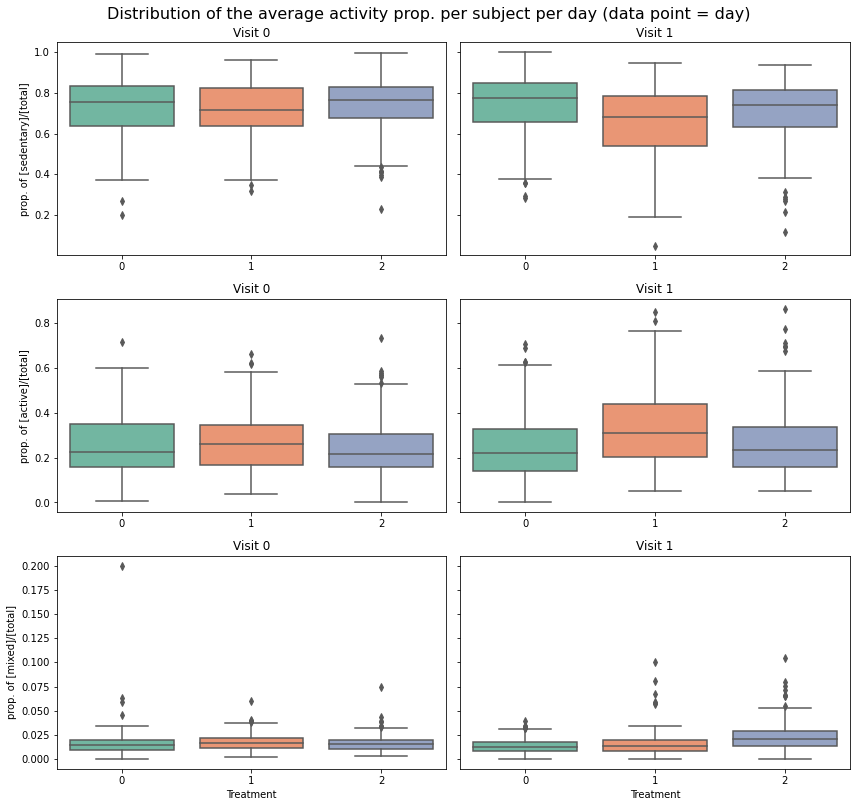

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

outcomes = ['cat3_sam_0_prop', 'cat3_sam_1_prop', 'cat3_sam_2_prop']
outcome_labels = ['prop. of [sedentary]/[total]', 
                  'prop. of [active]/[total]', 
                  'prop. of [mixed]/[total]']

visits = sorted(summary_df_fin['visit'].unique())

fig, axes = plt.subplots(
    nrows=len(outcomes), ncols=len(visits),
    figsize=(12, 12),
    sharey='row'
)

for i, outcome in enumerate(outcomes):
    for j, visit in enumerate(visits):
        ax = axes[i, j]
        sns.boxplot(
            data=summary_df_fin[summary_df_fin['visit'] == visit],
            x='treatment',
            y=outcome,
            ax=ax,
            palette='Set2'
        )
        ax.set_title(f'Visit {visit}')
        if j == 0:
            ax.set_ylabel(outcome_labels[i])
        else:
            ax.set_ylabel('')
        if i < len(outcomes) - 1:
            ax.set_xlabel('')
        else:
            ax.set_xlabel('Treatment')

plt.suptitle("Distribution of the average activity prop. per subject per day (data point = day)", fontsize=16, y=0.93)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


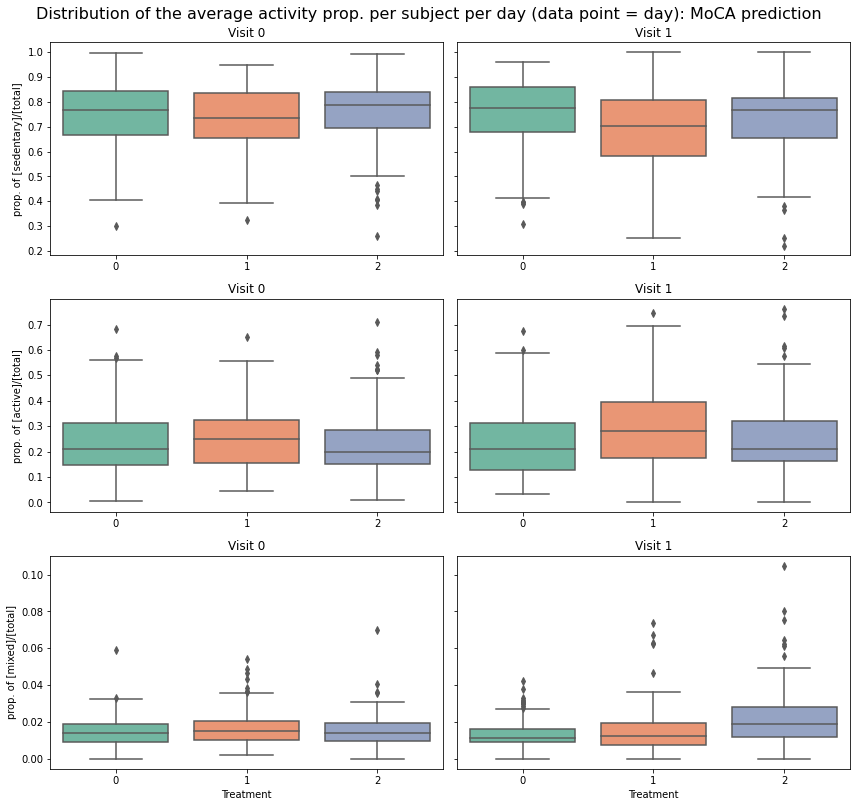

In [60]:
outcomes = ['cat3_sam_pred_0_prop', 'cat3_sam_pred_1_prop', 'cat3_sam_pred_2_prop']
outcome_labels = ['prop. of [sedentary]/[total]', 
                  'prop. of [active]/[total]', 
                  'prop. of [mixed]/[total]']

visits = sorted(summary_df_fin['visit'].unique())

fig, axes = plt.subplots(
    nrows=len(outcomes), ncols=len(visits),
    figsize=(12, 12),
    sharey='row'
)
for i, outcome in enumerate(outcomes):
    for j, visit in enumerate(visits):
        ax = axes[i, j]
        sns.boxplot(
            data=summary_df_fin[summary_df_fin['visit'] == visit],
            x='treatment',
            y=outcome,
            ax=ax,
            palette='Set2'
        )
        ax.set_title(f'Visit {visit}')
        if j == 0:
            ax.set_ylabel(outcome_labels[i])
        else:
            ax.set_ylabel('')
        if i < len(outcomes) - 1:
            ax.set_xlabel('')
        else:
            ax.set_xlabel('Treatment')

plt.suptitle("Distribution of the average activity prop. per subject per day (data point = day): MoCA prediction", fontsize=16, y=0.93)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
